In [1]:
#Importing Libraries
import tensorflow 
import numpy as np 
import pandas as pd 
from collections import Counter
import random
import IPython
from IPython.display import Image, Audio
import music21
from music21 import *
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adamax
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
import sys
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
np.random.seed(42)

c:\Poluare Software\Python\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import os
from music21 import converter

#Loading the list of chopin's midi files as stream 
filepath = "./classical-music-midi/chopin/"
#Getting midi files
all_midis= []
for i in os.listdir(filepath):
    if i.endswith(".mid"):
        tr = filepath+i
        midi = converter.parse(tr)
        all_midis.append(midi)

In [3]:
#Helping function        
def extract_notes(file):
    notes = []
    pick = None
    for j in file:
        songs = instrument.partitionByInstrument(j)
        for part in songs.parts:
            pick = part.recurse()
            for element in pick:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    notes.append(".".join(str(n) for n in element.normalOrder))

    return notes
#Getting the list of notes as Corpus
Corpus= extract_notes(all_midis)
print("Total notes in all the Chopin midis in the dataset:", len(Corpus))

Total notes in all the Chopin midis in the dataset: 57886


In [4]:
print("First fifty values in the Corpus:", Corpus[:50])

First fifty values in the Corpus: ['C5', '2.5', '9.0', 'C5', 'F3', 'F5', 'F2', '7.0', '9.0', 'F4', 'F3', 'C5', 'F2', '2.5', '9.0', 'C5', 'F3', 'F5', 'F2', '2.7', '10.0', 'C5', 'E3', 'G5', 'F2', '9.0', '10.0', 'G4', 'E3', 'C5', 'F2', '2.7', '10.0', 'C5', 'E3', 'G5', 'F2', '9.2', '9.0', 'C5', 'F3', 'A5', 'F2', '2.5', '9.2', 'C5', 'F3', 'F5', 'F2', '9.2']


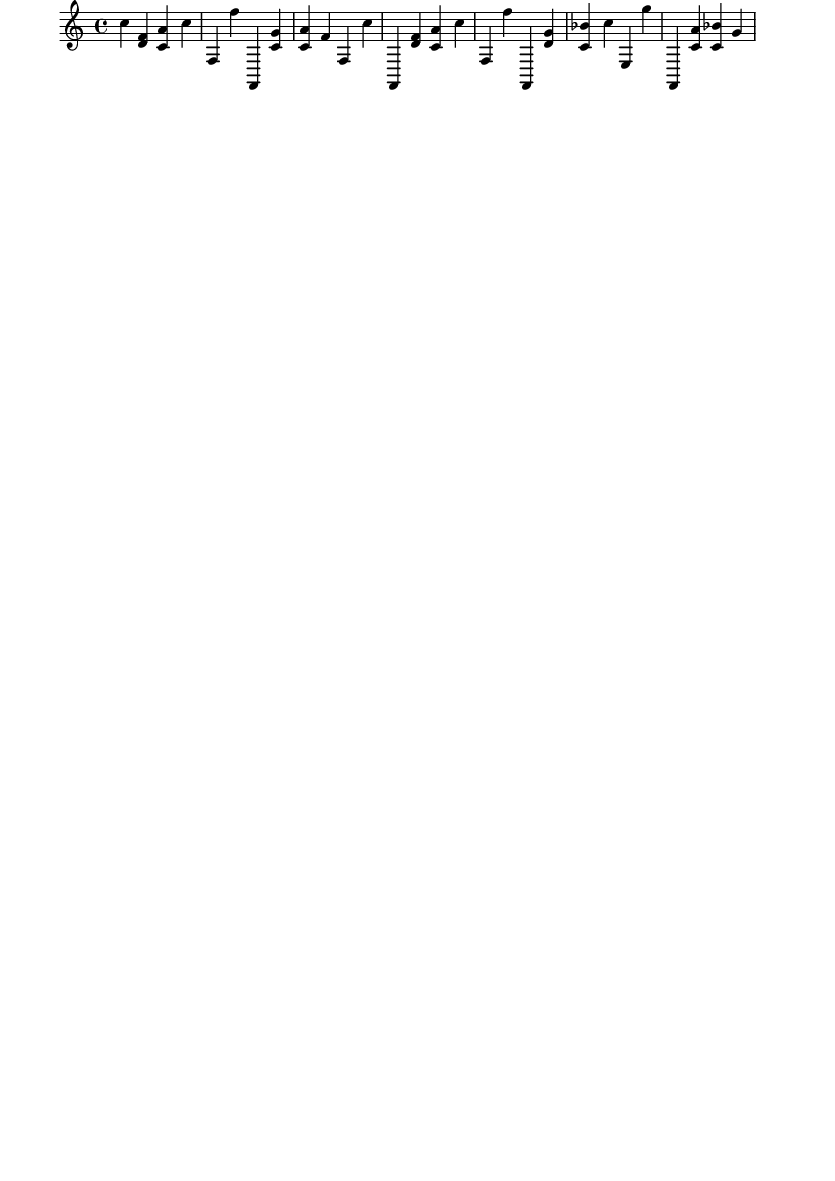

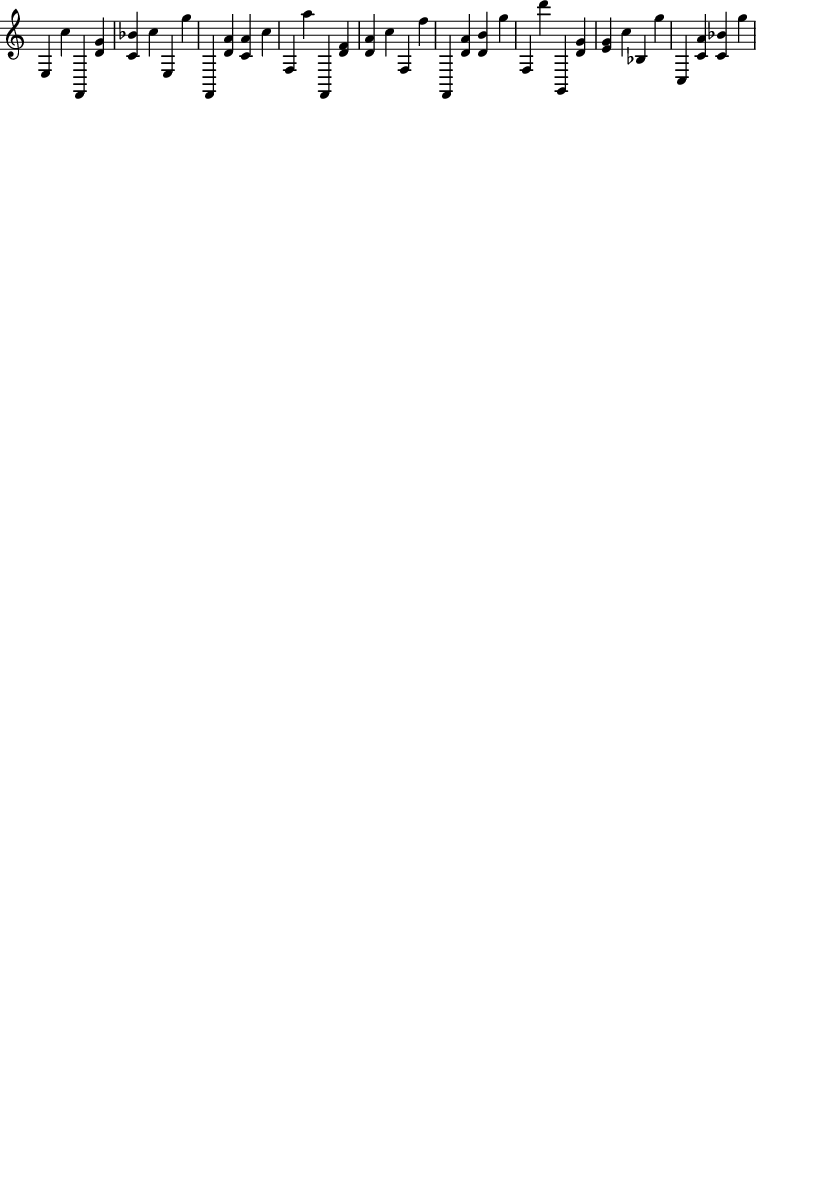

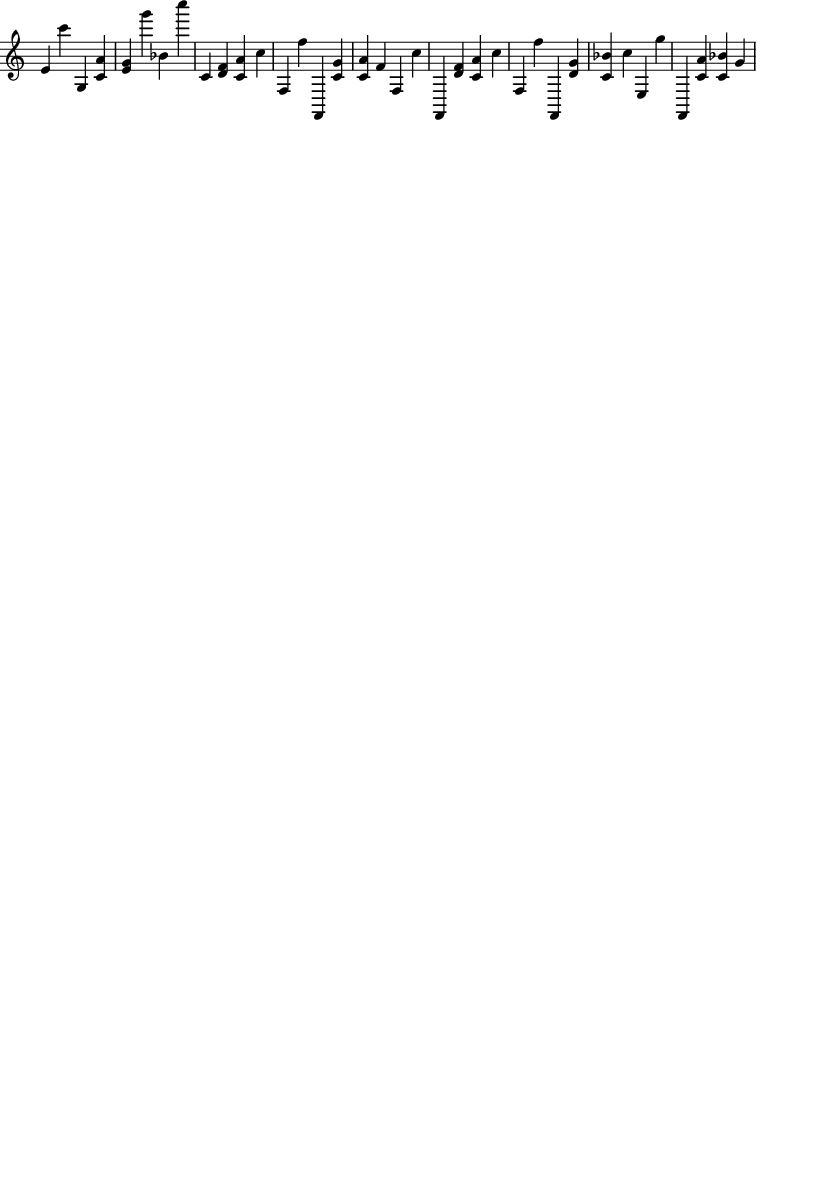

In [5]:
import re
from pathlib import Path
from IPython.display import Image, display

from music21 import note, chord, stream
from music21.lily.translate import LilyTranslateException

def show(music):
    ly_path = None

    try:
        # This runs LilyPond and attempts to return a PNG path
        out = music.write("lily.png")
        outp = Path(str(out))
        if outp.exists():
            display(Image(str(outp)))
            return

    except LilyTranslateException as e:
        # Extract the .ly path from the exception text:
        # "... original file was C:\...\tmpxxxx.ly"
        m = re.search(r"original file was (.*?\.ly)\b", str(e))
        if m:
            ly_path = Path(m.group(1))

    # Fallback: find LilyPond’s paged PNGs: tmpxxxx.ly-page1.png, -page2.png, ...
    if ly_path is None:
        # last-resort: search scratch for newest .ly
        scratch = Path.home() / "Documents" / "music21_scratch"
        ly_files = sorted(scratch.glob("*.ly"), key=lambda p: p.stat().st_mtime, reverse=True)
        if ly_files:
            ly_path = ly_files[0]
        else:
            raise FileNotFoundError("No .ly file found in music21_scratch")

    base = ly_path.name
    pages = sorted(ly_path.parent.glob(base + "-page*.png"))

    if not pages:
        # some setups produce tmpxxxx.ly.png (single page)
        single = ly_path.with_suffix(ly_path.suffix + ".png")
        if single.exists():
            pages = [single]

    if not pages:
        raise FileNotFoundError(f"No PNG pages found for {ly_path}")

    for p in pages:
        display(Image(str(p)))

def chords_n_notes(Snippet):
    Melody = []
    offset = 0
    for i in Snippet:
        if ("." in i) or i.isdigit():
            chord_notes = i.split(".")
            notes = [note.Note(int(j)) for j in chord_notes]
            chord_snip = chord.Chord(notes)
            chord_snip.offset = offset
            Melody.append(chord_snip)
        else:
            note_snip = note.Note(i)
            note_snip.offset = offset
            Melody.append(note_snip)
        offset += 1
    return stream.Stream(Melody)

Melody_Snippet = chords_n_notes(Corpus[:100])
show(Melody_Snippet)


In [6]:
#Creating a count dictionary
count_num = Counter(Corpus)
print("Total unique notes in the Corpus:", len(count_num))

Total unique notes in the Corpus: 397


In [7]:
#Exploring the notes dictionary
Notes = list(count_num.keys())
Recurrence = list(count_num.values())
#Average recurrenc for a note in Corpus
def Average(lst):
    return sum(lst) / len(lst)
print("Average recurrenc for a note in Corpus:", Average(Recurrence))
print("Most frequent note in Corpus appeared:", max(Recurrence), "times")
print("Least frequent note in Corpus appeared:", min(Recurrence), "time")

Average recurrenc for a note in Corpus: 145.80856423173805
Most frequent note in Corpus appeared: 1627 times
Least frequent note in Corpus appeared: 1 time


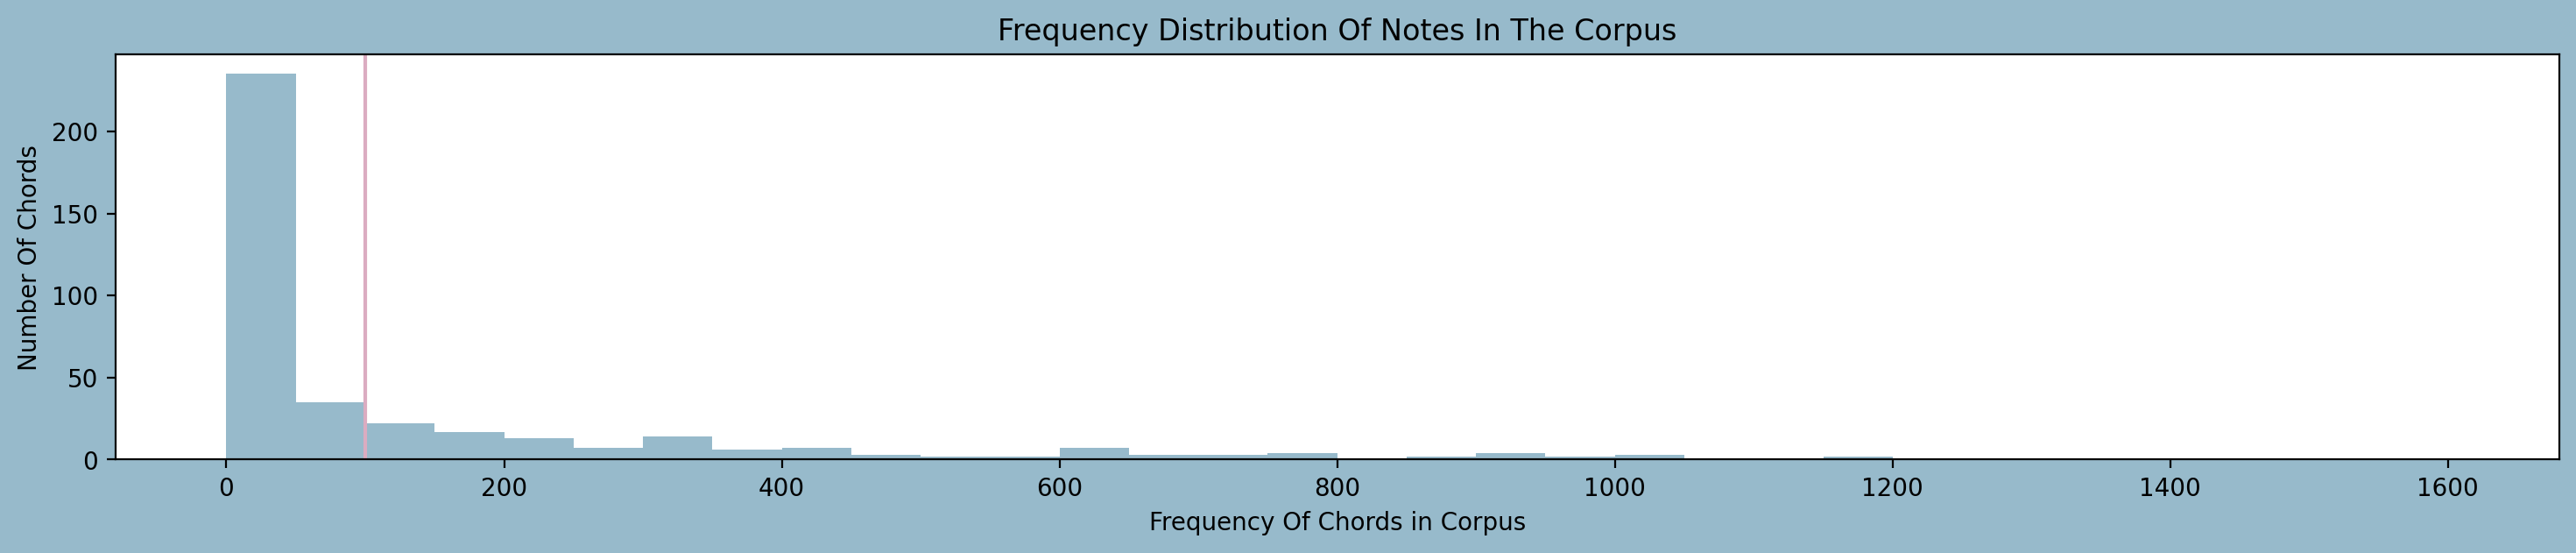

In [8]:
# Plotting the distribution of Notes
plt.figure(figsize=(18,3),facecolor="#97BACB")
bins = np.arange(0,(max(Recurrence)), 50) 
plt.hist(Recurrence, bins=bins, color="#97BACB")
plt.axvline(x=100,color="#DBACC1")
plt.title("Frequency Distribution Of Notes In The Corpus")
plt.xlabel("Frequency Of Chords in Corpus")
plt.ylabel("Number Of Chords")
plt.show()

In [9]:
#Getting a list of rare chords
rare_note = []
for index, (key, value) in enumerate(count_num.items()):
    if value < 100:
        m =  key
        rare_note.append(m)
        
print("Total number of notes that occur less than 100 times:", len(rare_note))

Total number of notes that occur less than 100 times: 270


In [10]:
#Eleminating the rare notes
for element in Corpus:
    if element in rare_note:
        Corpus.remove(element)

print("Length of Corpus after elemination the rare notes:", len(Corpus))

Length of Corpus after elemination the rare notes: 53737


In [11]:
# Storing all the unique characters present in my corpus to bult a mapping dic. 
symb = sorted(list(set(Corpus)))

L_corpus = len(Corpus) #length of corpus
L_symb = len(symb) #length of total unique characters

#Building dictionary to access the vocabulary from indices and vice versa
mapping = dict((c, i) for i, c in enumerate(symb))
reverse_mapping = dict((i, c) for i, c in enumerate(symb))

print("Total number of characters:", L_corpus)
print("Number of unique characters:", L_symb)

Total number of characters: 53737
Number of unique characters: 256


In [12]:
#Splitting the Corpus in equal length of strings and output target
length = 40
features = []
targets = []
for i in range(0, L_corpus - length, 1):
    feature = Corpus[i:i + length]
    target = Corpus[i + length]
    features.append([mapping[j] for j in feature])
    targets.append(mapping[target])
    
    
L_datapoints = len(targets)
print("Total number of sequences in the Corpus:", L_datapoints)

Total number of sequences in the Corpus: 53697


In [13]:
# reshape X and normalize
X = (np.reshape(features, (L_datapoints, length, 1)))/ float(L_symb)
# one hot encode the output variable
y = tensorflow.keras.utils.to_categorical(targets) 

In [14]:
#Taking out a subset of data to be used as seed
X_train, X_seed, y_train, y_seed = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
#Initialising the Model
model = Sequential()
#Adding layers
model.add(LSTM(512, input_shape=(X.shape[1], X.shape[2]), return_sequences=True))
model.add(Dropout(0.1))
model.add(LSTM(256))
model.add(Dense(256))
model.add(Dropout(0.1))
model.add(Dense(y.shape[1], activation='softmax'))
#Compiling the model for training  
opt = Adamax(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=opt)

In [16]:
#Model's Summary               
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 512)        │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,971,712 (7.52 MB)

 Trainable params: 1,971,712 (7.52 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#Training the Model
history = model.fit(X_train, y_train, batch_size=256, epochs=200)

Epoch 1/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 35s 203ms/step - loss: 4.7584
Epoch 2/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 34s 203ms/step - loss: 4.6847
Epoch 3/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 34s 204ms/step - loss: 4.6429
Epoch 4/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 34s 204ms/step - loss: 4.5994
Epoch 5/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 34s 205ms/step - loss: 4.5353
Epoch 6/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 36s 216ms/step - loss: 4.4824
Epoch 7/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 37s 220ms/step - loss: 4.4519
Epoch 8/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 37s 219ms/step - loss: 4.4417
Epoch 9/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 36s 213ms/step - loss: 4.4319
Epoch 10/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 36s 217ms/step - loss: 4.4287
Epoch 11/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 38s 229ms/step - loss: 4.4157
Epoch 12/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 38s 225ms/step - loss: 4.4103
Epoch 13/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 38s 223ms/step - loss: 4.3970
Epoch 14/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 38s 227ms/step - loss: 4.3845
E

[Text(0.5, 0, 'Epochs')]

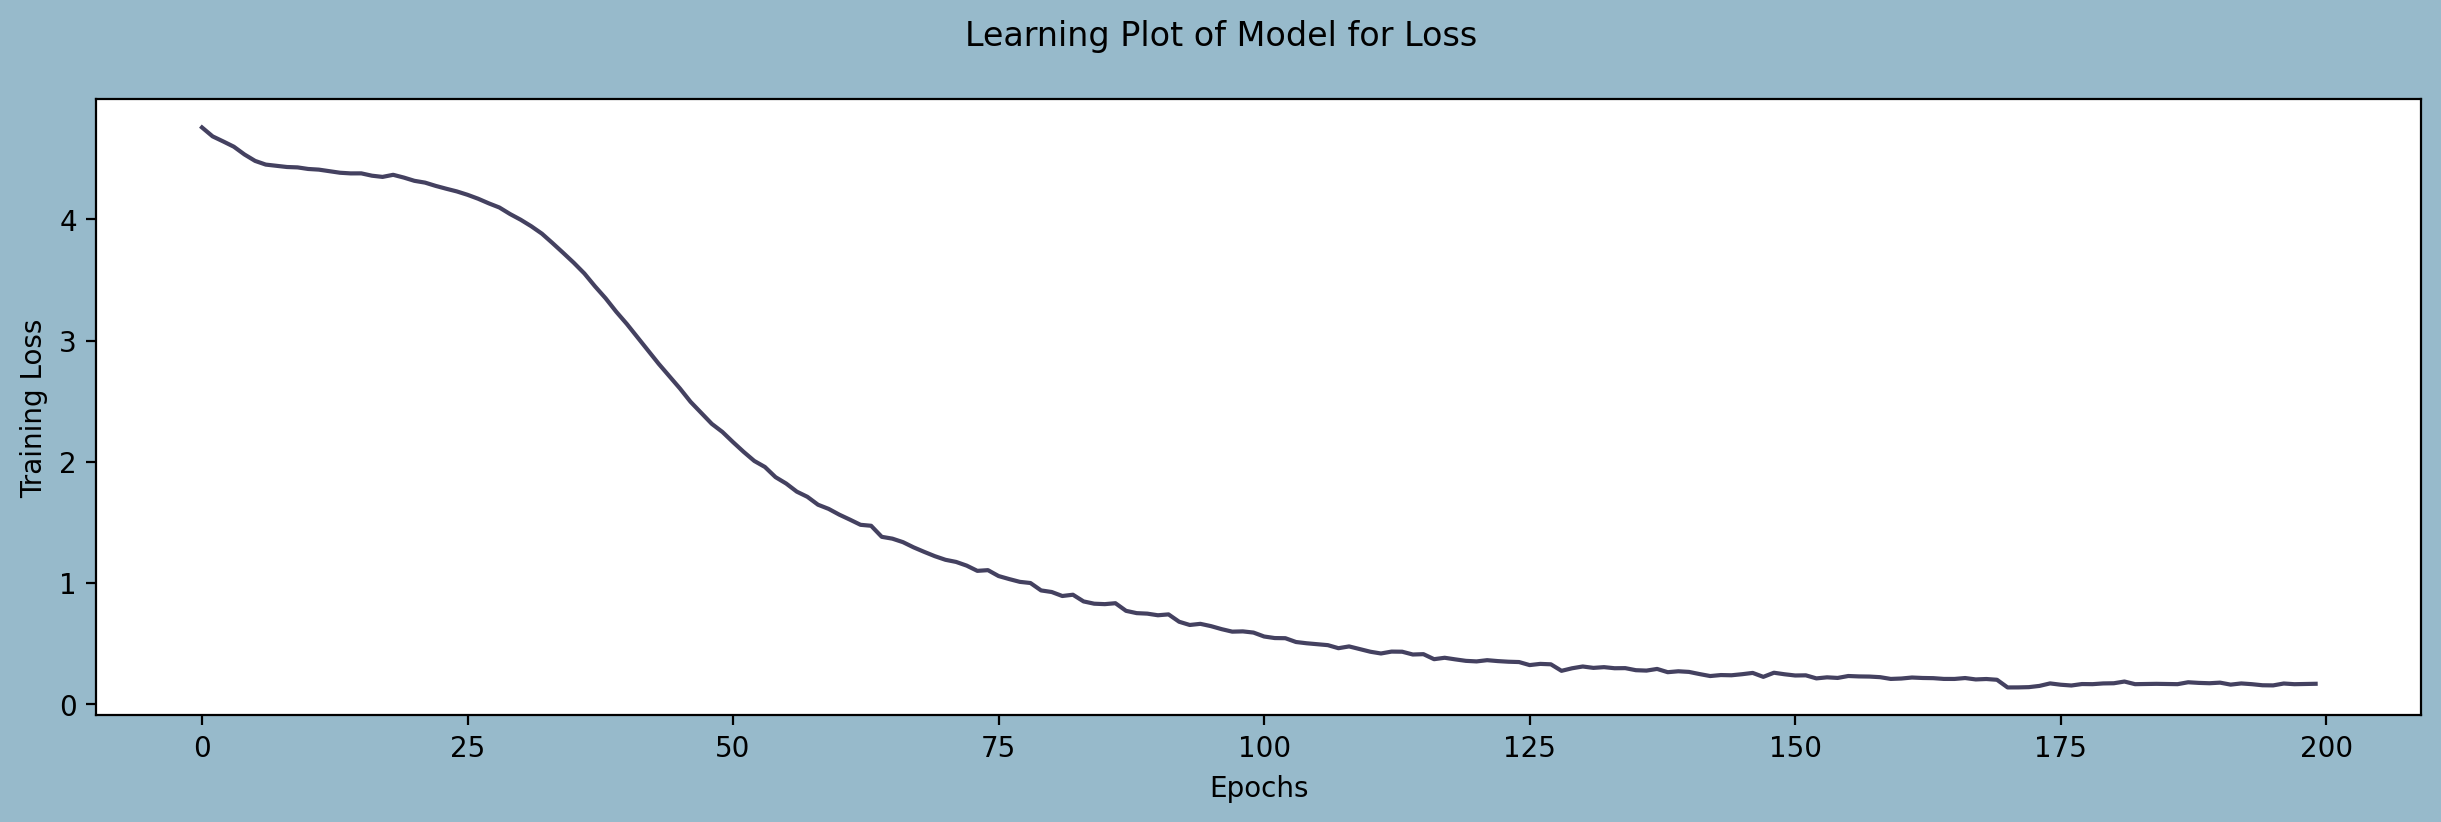

In [18]:
#Plotting the learnings 
history_df = pd.DataFrame(history.history)
fig = plt.figure(figsize=(15,4), facecolor="#97BACB")
fig.suptitle("Learning Plot of Model for Loss")
pl=sns.lineplot(data=history_df["loss"],color="#444160")
pl.set(ylabel ="Training Loss")
pl.set(xlabel ="Epochs")

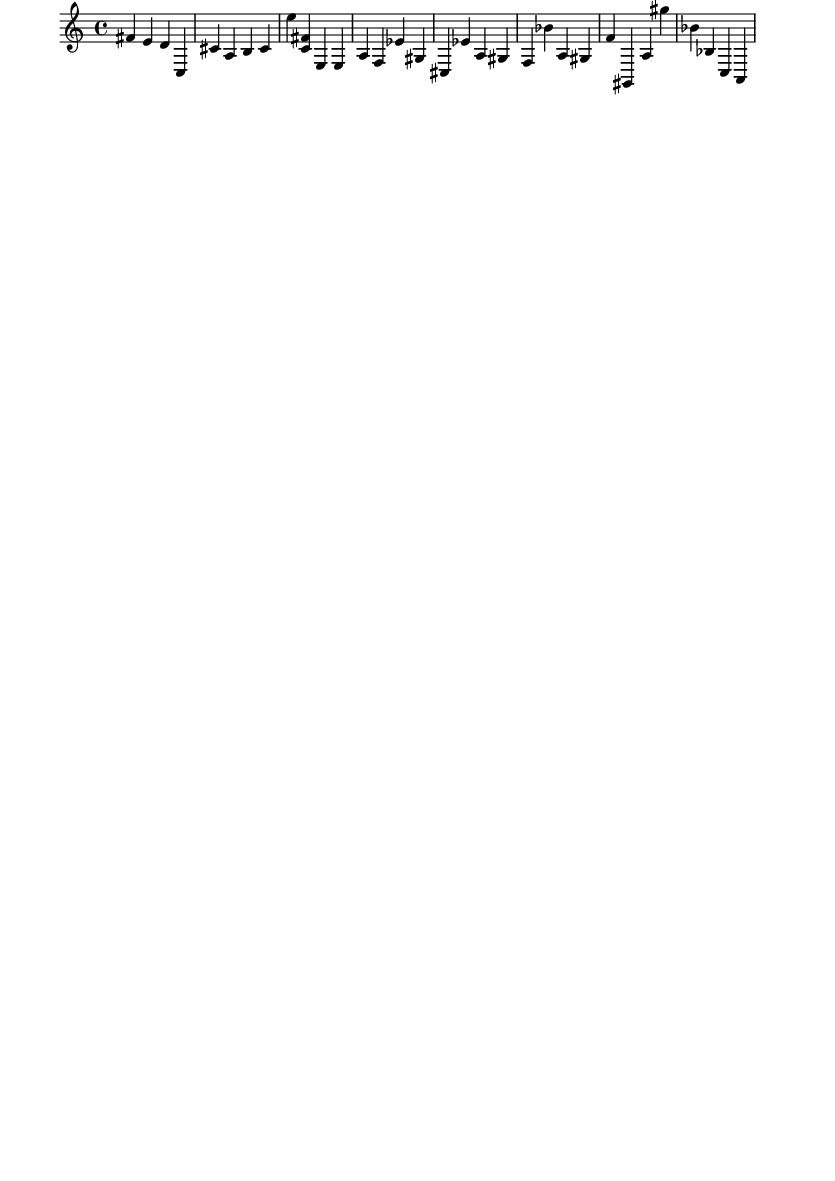

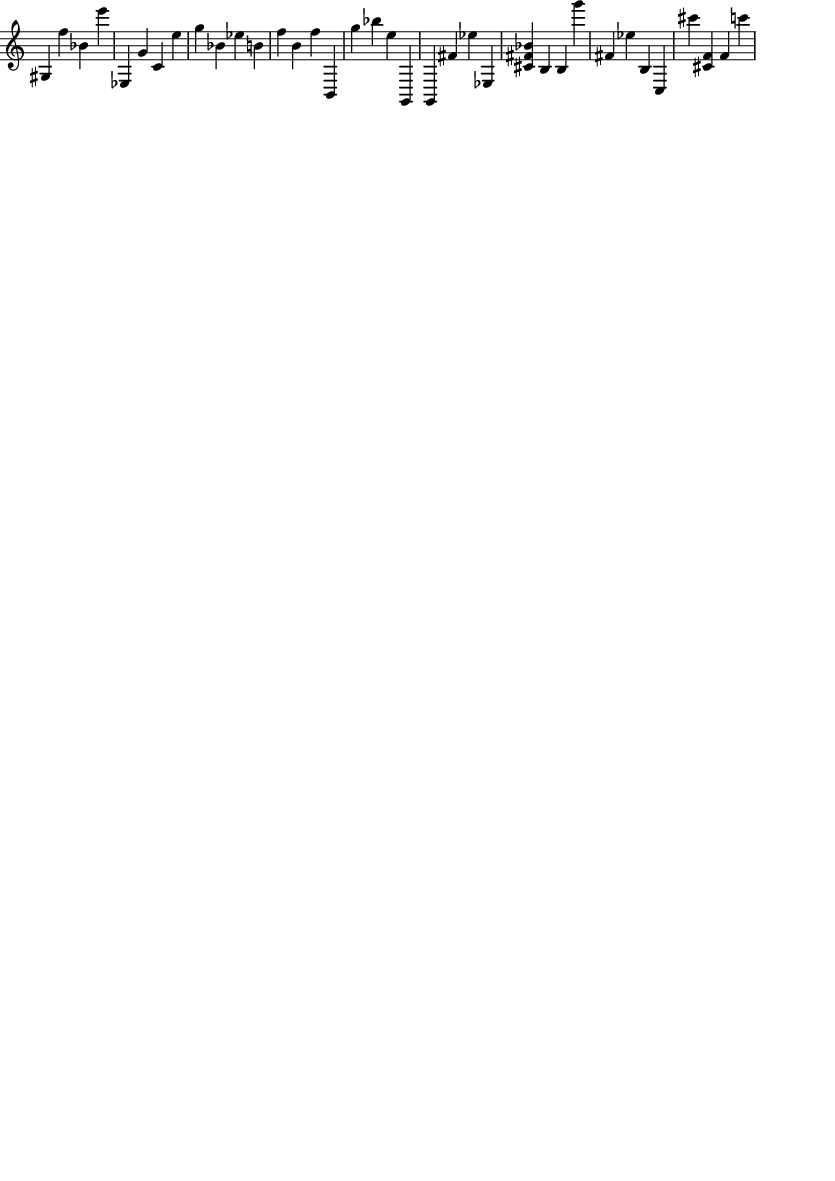

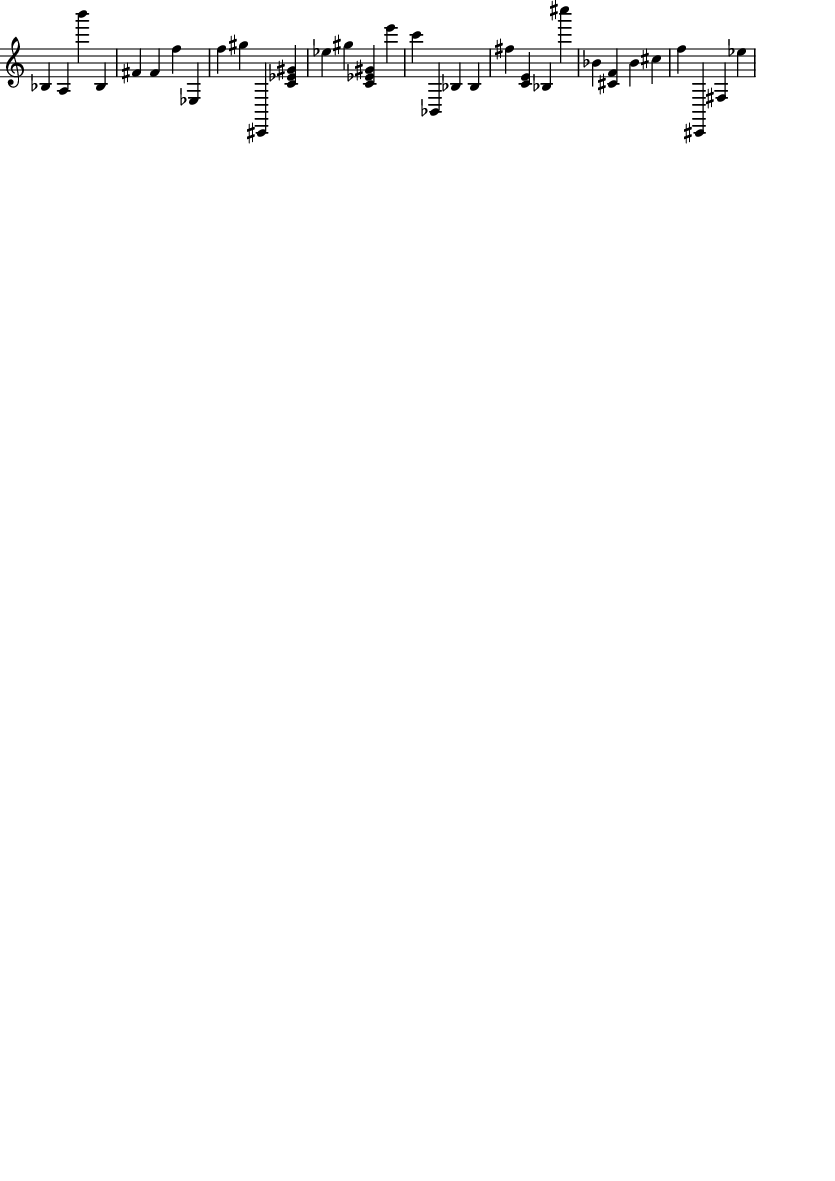

In [19]:
def Malody_Generator(Note_Count):
    seed = X_seed[np.random.randint(0,len(X_seed)-1)]
    Music = ""
    Notes_Generated=[]
    for i in range(Note_Count):
        seed = seed.reshape(1,length,1)
        prediction = model.predict(seed, verbose=0)[0]
        prediction = np.log(prediction) / 1.0 #diversity
        exp_preds = np.exp(prediction)
        prediction = exp_preds / np.sum(exp_preds)
        index = np.argmax(prediction)
        index_N = index/ float(L_symb)   
        Notes_Generated.append(index)
        Music = [reverse_mapping[char] for char in Notes_Generated]
        seed = np.insert(seed[0],len(seed[0]),index_N)
        seed = seed[1:]
    #Now, we have music in form or a list of chords and notes and we want to be a midi file.
    Melody = chords_n_notes(Music)
    Melody_midi = stream.Stream(Melody)   
    return Music,Melody_midi


#getting the Notes and Melody created by the model
Music_notes, Melody = Malody_Generator(100)
show(Melody)

In [20]:
#To save the generated melody
Melody.write('midi','Melody_Generated.mid')

from IPython.display import display
Melody.show('midi')
